# Part 2: EDA Featurization
Now that we have the data, we look at the size and shape of the dataset and perform some key visualizations.<br>
We need to make sure that we have removed any null values before we begin visualization.<br>
One of the most important things to take a look at is the overall magnetic moment data distribution- that is what we want our model to predict.<br>
We also take a look at what distribution function best fits the distribution of only the magnetic halides.<br>

In [34]:
#816 compounds were retrieved.  Using Gemini, turn this into a dataframe
data = []
for doc in all_results:
    #Get magnetization/atomic sites for below calculation
    total_mag = getattr(doc, "total_magnetization", 0.0) or 0.0
    num_atoms = getattr(doc, "nsites", 1)  # Default to 1 to avoid division by zero
    
    mag_per_atom = total_mag / num_atoms

    data.append({
        "Material ID": str(doc.material_id),
        "Formula": doc.formula_pretty,
        "Crystal System": str(doc.symmetry.crystal_system),
        "Space Group": str(doc.symmetry.symbol),
        "Total Magnetization (µB)": total_mag, 
        "Magnetization per Atom (µB/atom)": mag_per_atom,
        "Num Atoms": num_atoms,
        "Is Stable": doc.is_stable
    })

mat_df = pd.DataFrame(data)
print(f"Base DataFrame built with {len(mat_df)} rows.")
print(f"Dimensions of dataframe:{mat_df.shape}")
print(f"Statistics for Magnetic Moments per Atom:")
print(mat_df['Magnetization per Atom (µB/atom)'].describe())

#Use this to get the dataframe to display on 1 single row (Gemini)
pd.set_option('display.max_columns', None)  # Show all columns without truncation
pd.set_option('display.width', 1000)
#Display unsorted DataFrame
print(mat_df.head(10))

#Sort by normalized magnetic moment highest to lowest
mat_df_sorted = mat_df.sort_values(by="Magnetization per Atom (µB/atom)", ascending=False)
#Then print the first 10 rows of the sorted DataFrame
print(f"\nCompounds sorted by magnetic moment (µB)")
print(mat_df_sorted.head(10))
print(f"The compounds with the largest magnetic moments per atom are mostly Mn compounds.\nWith the exception of MnI2 and MnF2, all are unstable.\nIt seems like the magnitude of the magnetism of a compound may contribute to instability.")

Base DataFrame built with 816 rows.
Dimensions of dataframe:(816, 8)
Statistics for Magnetic Moments per Atom:
count    816.000000
mean       0.233167
std        0.410119
min        0.000000
25%        0.000000
50%        0.000108
75%        0.317558
max        3.099893
Name: Magnetization per Atom (µB/atom), dtype: float64
  Material ID Formula Crystal System Space Group  Total Magnetization (µB)  Magnetization per Atom (µB/atom)  Num Atoms  Is Stable
0  mp-1183996    Cu3F      Hexagonal    P6_3/mmc                  0.038672                          0.004834          8      False
1    mp-10634     CuF          Cubic       F-43m                  0.020022                          0.010011          2      False
2     mp-1229    CuF2     Monoclinic      P2_1/c                  2.000000                          0.333333          6       True
3  mp-1147670    CuF2     Tetragonal      I4/mmm                  0.359945                          0.119982          3      False
4  mp-1147672    Cu

In [35]:
#Import MAGPIE data- Gemini helped me do this (doing it myself is hopeless)
from pymatgen.core import Composition
from matminer.featurizers.composition import ElementProperty

print("Converting formulas to composition objects...")

#The original code I had started erroring unexpectedly and Gemini had to help me debug
def safe_parse_composition(formula_str):
    try:
        return Composition(formula_str)
    except Exception:
        return None

mat_df["composition"] = mat_df["Formula"].apply(safe_parse_composition)

# Drop any rows where formula conversion failed
mat_df = mat_df.dropna(subset=["composition"]).reset_index(drop=True)

ep = ElementProperty.from_preset(preset_name="magpie")

print("Calculating MAGPIE features...")
mat_df = ep.featurize_dataframe(mat_df, col_id="composition", ignore_errors=True)

#Removing that old column
mat_df = mat_df.drop(columns=["composition"])

magpie_cols = [c for c in mat_df.columns if 'MagpieData' in c]
print(f"\nSUCCESS! MAGPIE feature columns found: {len(magpie_cols)}")
print(f"Example features: {magpie_cols[:3]}")

Converting formulas to composition objects...
Calculating MAGPIE features...


ElementProperty:   0%|          | 0/816 [00:00<?, ?it/s]


SUCCESS! MAGPIE feature columns found: 132
Example features: ['MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number']


In [36]:
#Mimic week 5.  Drop compounds with null magnetization and report the results.

n_before = len(mat_df)

# Drop rows missing the target
mat_df = mat_df.dropna(subset=["Magnetization per Atom (µB/atom)"])

n_after = len(mat_df)
print(f'Rows before: {n_before:,}')
print(f'Rows after:  {n_after:,}')
print(f'Dropped:     {n_before - n_after:,} ({100*(n_before-n_after)/n_before:.1f}%)')
print(f'\nMagnetic moment range: {mat_df["Magnetization per Atom (µB/atom)"].min():.2f} \u2013 {mat_df["Magnetization per Atom (µB/atom)"].max():.2f} µB/atom')
if n_before == n_after:
    print(f"All compounds have a reported magnetic moment.")

Rows before: 816
Rows after:  816
Dropped:     0 (0.0%)

Magnetic moment range: 0.00 – 3.10 µB/atom
All compounds have a reported magnetic moment.


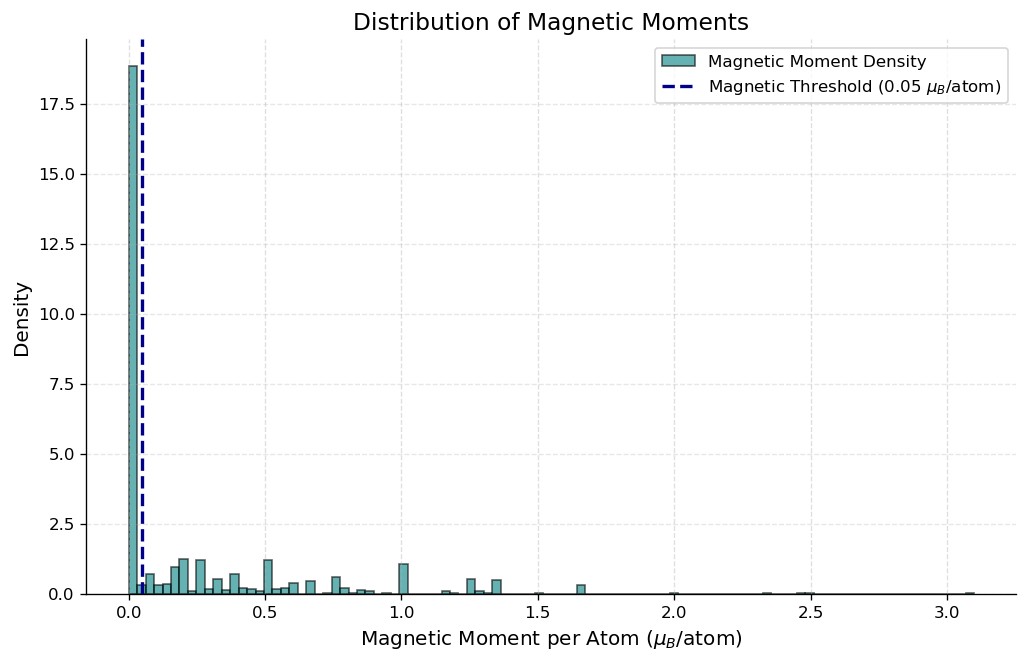

This data is heavily right-skewed- similar to the bandgap data we saw in Week 5.
The graph extends up to ~3 (max magnetic moment) even though the compounds with that magnitude are almost nil.


In [37]:
#Before we begin training- make sure that we see how the data is distributed
from scipy.stats import norm
from scipy.stats import lognorm

#Gemini helped me write this (found me the code for the specific visualization
mat_atom_data = mat_df['Magnetization per Atom (µB/atom)']

plt.figure(figsize=(10, 6))

plt.hist(mat_atom_data, bins=100, density=True, alpha=0.6, color='teal', edgecolor='black', label='Magnetic Moment Density')

#I tried to overlay a Gaussian curve over the data but it's almost useless to see so we're not doing that.

#The literature threshold is 0.05 uB/atom to be considered magnetic so we will add a line in the distribution
threshold = 0.05

#Line representing magnetism
plt.axvline(x=threshold, color='darkblue', linestyle='--', linewidth=2, label=f'Magnetic Threshold ({threshold} $\mu_B$/atom)')
plt.title('Distribution of Magnetic Moments', fontsize=14)
plt.xlabel('Magnetic Moment per Atom ($\mu_B$/atom)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
#We have to save it in a file on the same level
plt.savefig(os.path.join(output_dir, '02_magmom_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"This data is heavily right-skewed- similar to the bandgap data we saw in Week 5.\nThe graph extends up to ~3 (max magnetic moment) even though the compounds with that magnitude are almost nil.")

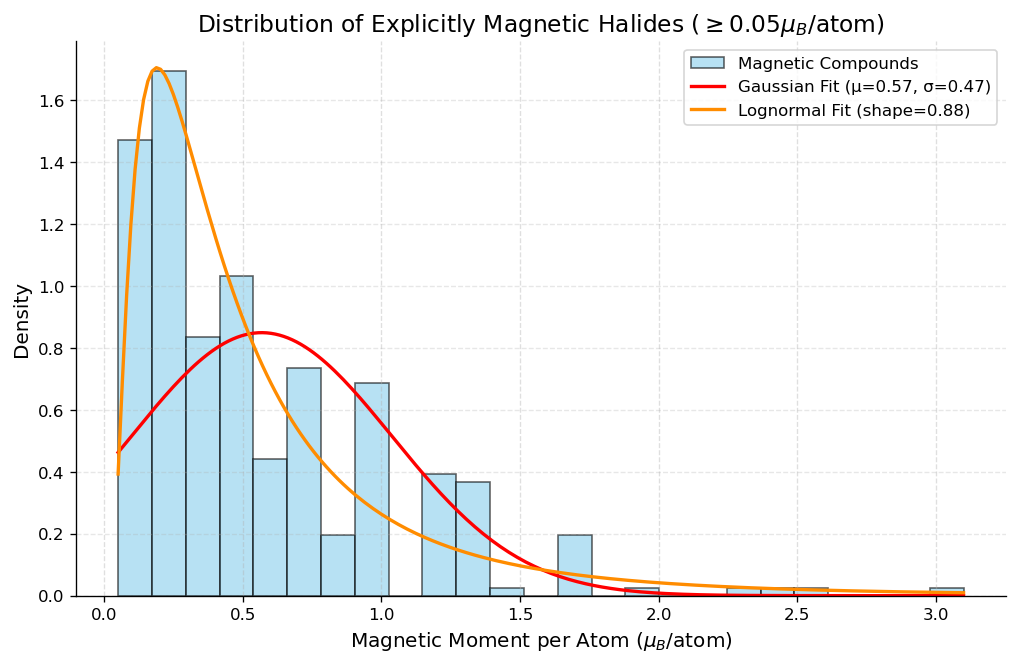

Out of 816 total materials, 334 are actively magnetic.
The data is still right-skewed considering just the magnetic compounds (334), so a lognormal fit is very accurate.


In [38]:
#Due to how right-skewed the data is (zero magnetization compounds dominate), you can't really see how the distributions fit
#So we're splitting the data into magnetic/nonmagnetic bins and plotting it again on just the magnetic compounds (Gemini helped me)

#Filter to only compounds that are magnetic (literature threshold)
magnetic_data = mat_df[mat_df['Magnetization per Atom (µB/atom)'] >= 0.05]['Magnetization per Atom (µB/atom)']

mu_mag, std_mag = magnetic_data.mean(), magnetic_data.std()
shape_mag, loc_mag, scale_mag = lognorm.fit(magnetic_data)

plt.figure(figsize=(10, 6))
plt.hist(magnetic_data, bins=25, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Magnetic Compounds')

#For distribution curves
x_vals = np.linspace(magnetic_data.min(), magnetic_data.max(), 200)

plt.plot(x_vals, norm.pdf(x_vals, mu_mag, std_mag), color='red', linewidth=2, 
         label=f'Gaussian Fit (μ={mu_mag:.2f}, σ={std_mag:.2f})')
plt.plot(x_vals, lognorm.pdf(x_vals, shape_mag, loc_mag, scale_mag), color='darkorange', linewidth=2,
         label=f'Lognormal Fit (shape={shape_mag:.2f})')

plt.title('Distribution of Explicitly Magnetic Halides ($\geq 0.05 \mu_B$/atom)', fontsize=14)
plt.xlabel('Magnetic Moment per Atom ($\mu_B$/atom)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig(os.path.join(output_dir, '02_magnetic_magmom_distribution'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Out of {len(mat_df)} total materials, {len(magnetic_data)} are actively magnetic.")
print(f"The data is still right-skewed considering just the magnetic compounds (334), so a lognormal fit is very accurate.")